# Assignment 1: Basic EDA

1. Read in the "Computers.csv" file. 
2. Explore the target variable, "price". Look at a histogram and boxplot of it.
3. Then, produce histograms of the 'speed' and 'ram' variables. 
4. Feel free to further explore the dataset!

In [42]:
import pandas as pd
import seaborn as sns

computers = pd.read_csv("c:\\Users\\donat\\iCloudDrive\\Documents\\BIT Data Analytics\\practice\\VSCode\\data/Computers.csv")

computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


In [43]:
computers.info()

<class 'pandas.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   price    6259 non-null   int64
 1   speed    6259 non-null   int64
 2   hd       6259 non-null   int64
 3   ram      6259 non-null   int64
 4   screen   6259 non-null   int64
 5   cd       6259 non-null   str  
 6   multi    6259 non-null   str  
 7   premium  6259 non-null   str  
 8   ads      6259 non-null   int64
 9   trend    6259 non-null   int64
dtypes: int64(7), str(3)
memory usage: 489.1 KB


In [44]:
computers.describe()

,price,speed,hd,ram,screen,ads,trend
count,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000,6259.000000
mean,2219.576610,52.011024,416.601694,8.286947,14.608723,221.301007,15.926985
std,580.803956,21.157735,258.548445,5.631099,0.905115,74.835284,7.873984
min,949.000000,25.000000,80.000000,2.000000,14.000000,39.000000,1.000000
25%,1794.000000,33.000000,214.000000,4.000000,14.000000,162.500000,10.000000
50%,2144.000000,50.000000,340.000000,8.000000,14.000000,246.000000,16.000000
75%,2595.000000,66.000000,528.000000,8.000000,15.000000,275.000000,21.500000
max,5399.000000,100.000000,2100.000000,32.000000,17.000000,339.000000,35.000000


<Axes: xlabel='price', ylabel='Count'>

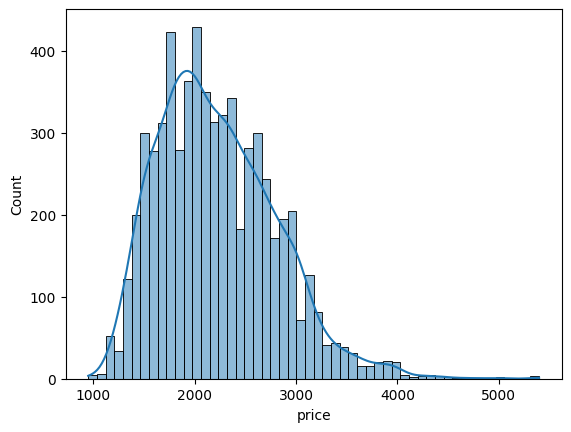

In [11]:
# Explore the target variable, "price". Look at a histogram and boxplot of it
sns.histplot(computers["price"], kde=True)

<Axes: xlabel='price'>

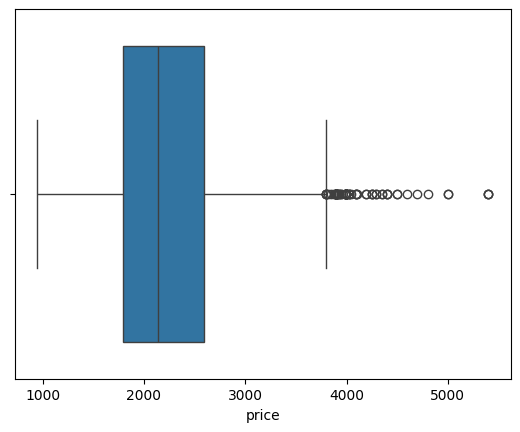

In [12]:
sns.boxplot(x=computers["price"])

<Axes: xlabel='speed', ylabel='count'>

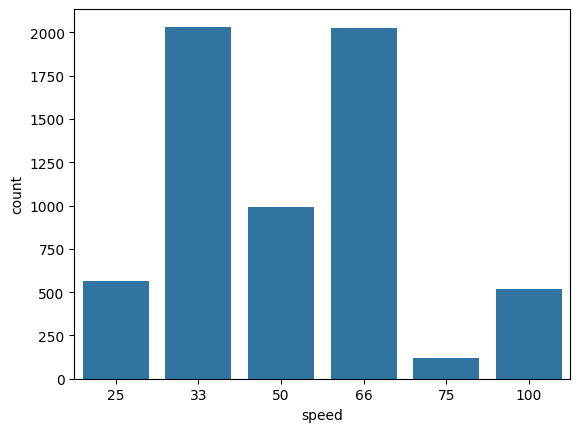

In [49]:
# sns.histplot(computers["speed"], kde=True, bins=5)
# i need to fix the above histplot, since there are big gaps betwen speed values, and the histogram is not showing the distribution well. I will use a boxplot instead to show the distribution of speed.
# sns.boxplot(x=computers["speed"])
sns.countplot(x=computers["speed"])

<Axes: xlabel='speed', ylabel='Count'>

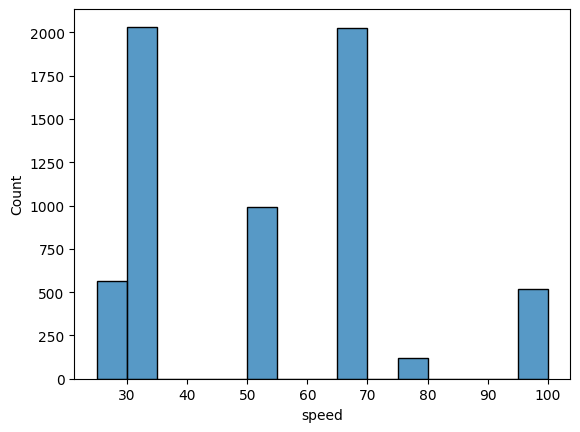

In [50]:
sns.histplot(computers["speed"], bins=15, kde=False)

<Axes: xlabel='speed', ylabel='price'>

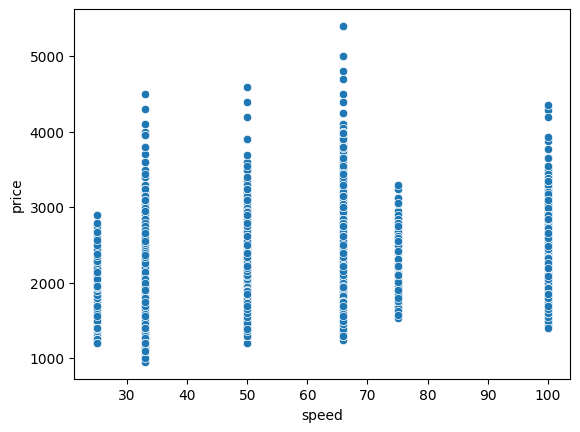

In [52]:
sns.scatterplot(data=computers, x="speed", y="price")

<Axes: xlabel='speed', ylabel='price'>

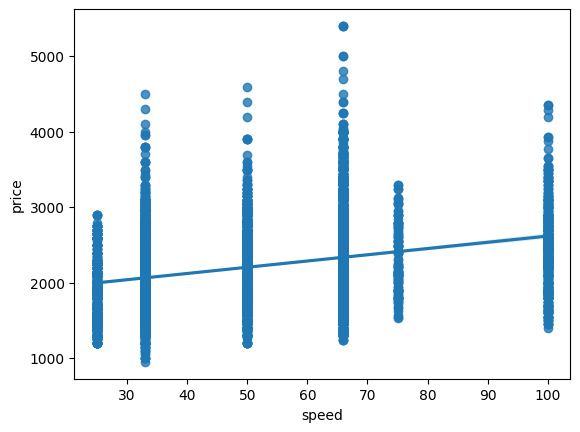

In [53]:
sns.regplot(data=computers, x="speed", y="price")

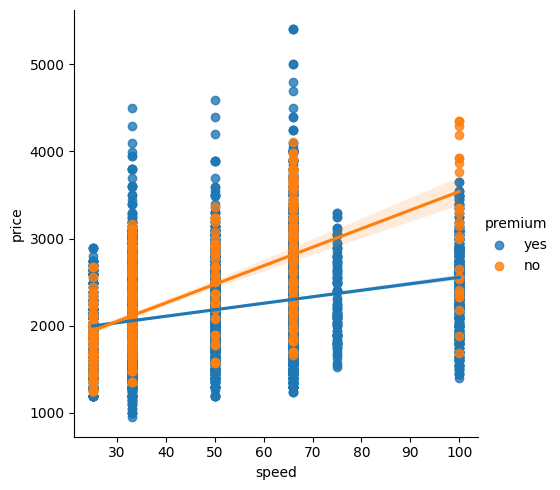

In [54]:
sns.lmplot(data=computers, x="speed", y="price", hue="premium")

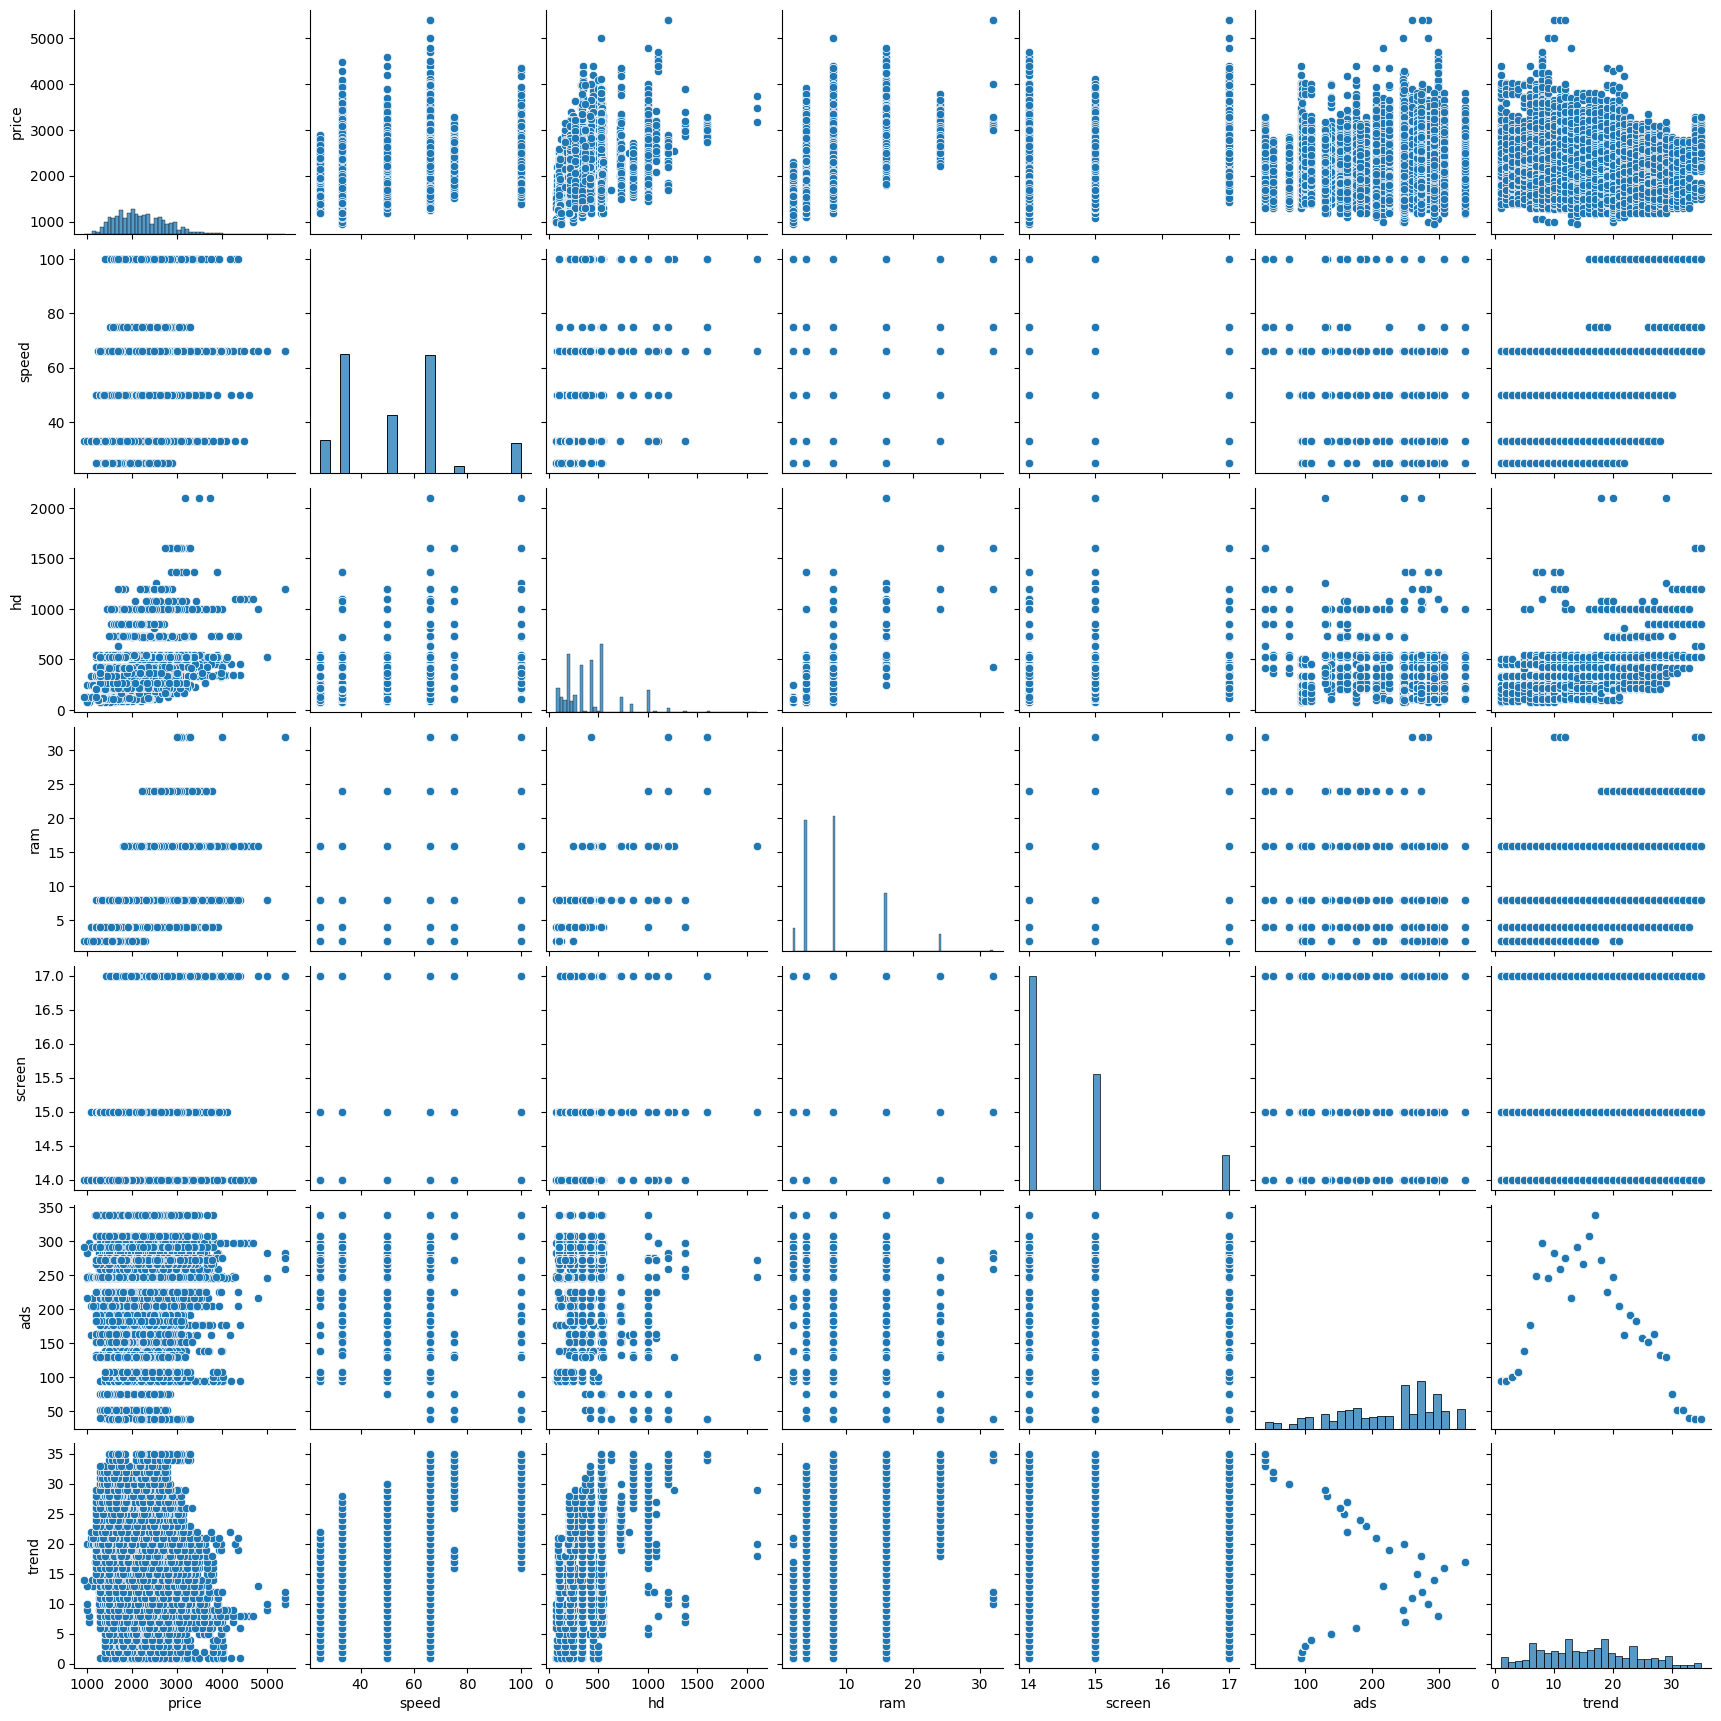

In [55]:
sns.pairplot(computers)

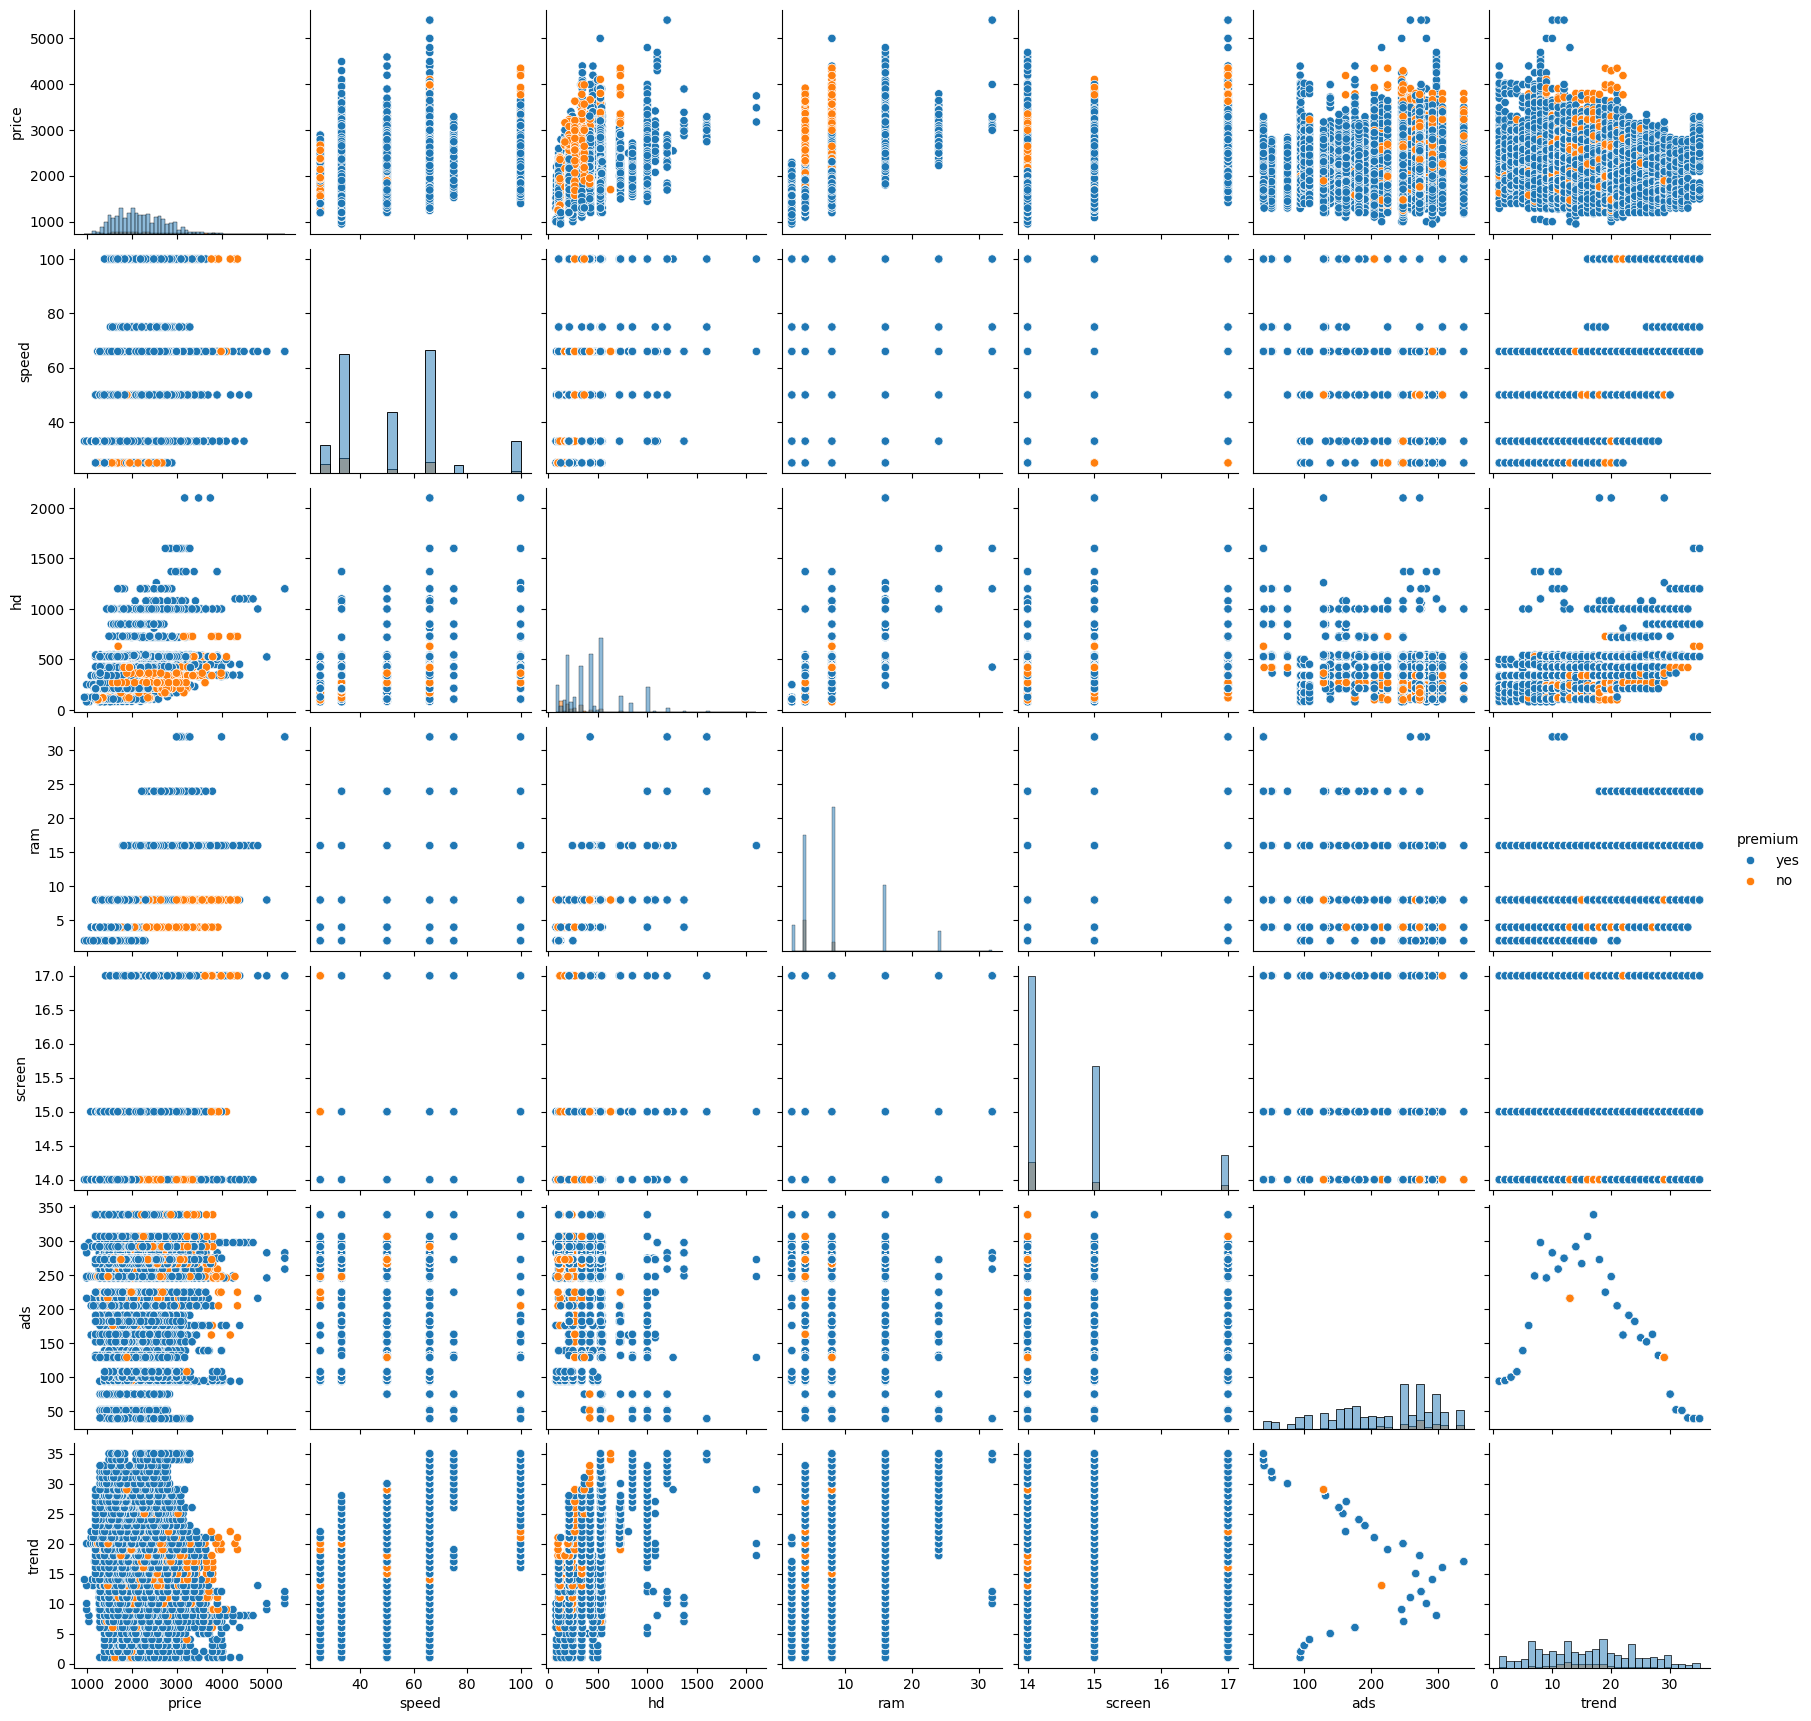

In [57]:
sns.pairplot(
    computers,
    hue="premium",
    diag_kind="hist"
)

<Axes: xlabel='ram'>

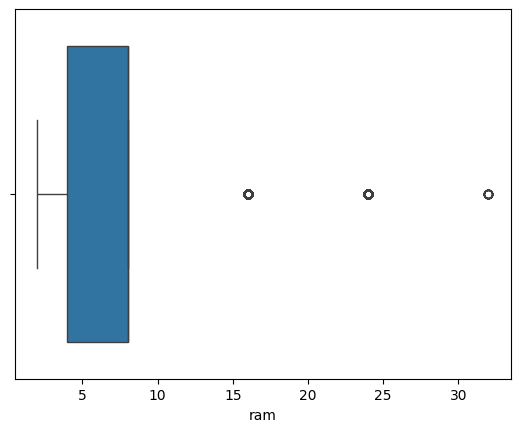

In [ ]:
sns.boxplot(x=computers["ram"])

In [26]:
computers.dtypes
computers.shape
computers.columns
computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


## Assignment 2: Variable Relationships

1. Build a correlation matrix of numeric features and pass it into a heatmap
2. Build a pairplot of numeric features in the data. Hint: df.select_dtypes("number") selects numeric columns. Consider sampling with df.sample(1000) to speed this up if it takes too long.
3. Build an lmplot of ram vs. price. Does being a premium model (premium == 'yes') impact this relationship? 

In [30]:
# #Build a correlation matrix of numeric features
computers.corr(numeric_only=True)

,price,speed,hd,ram,screen,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,-0.093919,0.188614
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,-0.318553,1.000000


<Axes: >

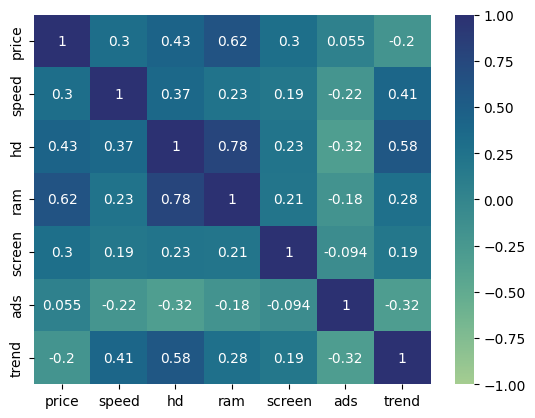

In [ ]:
#Build a correlation matrix of numeric features and pass it into a heatmap
sns.heatmap(computers.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="crest")


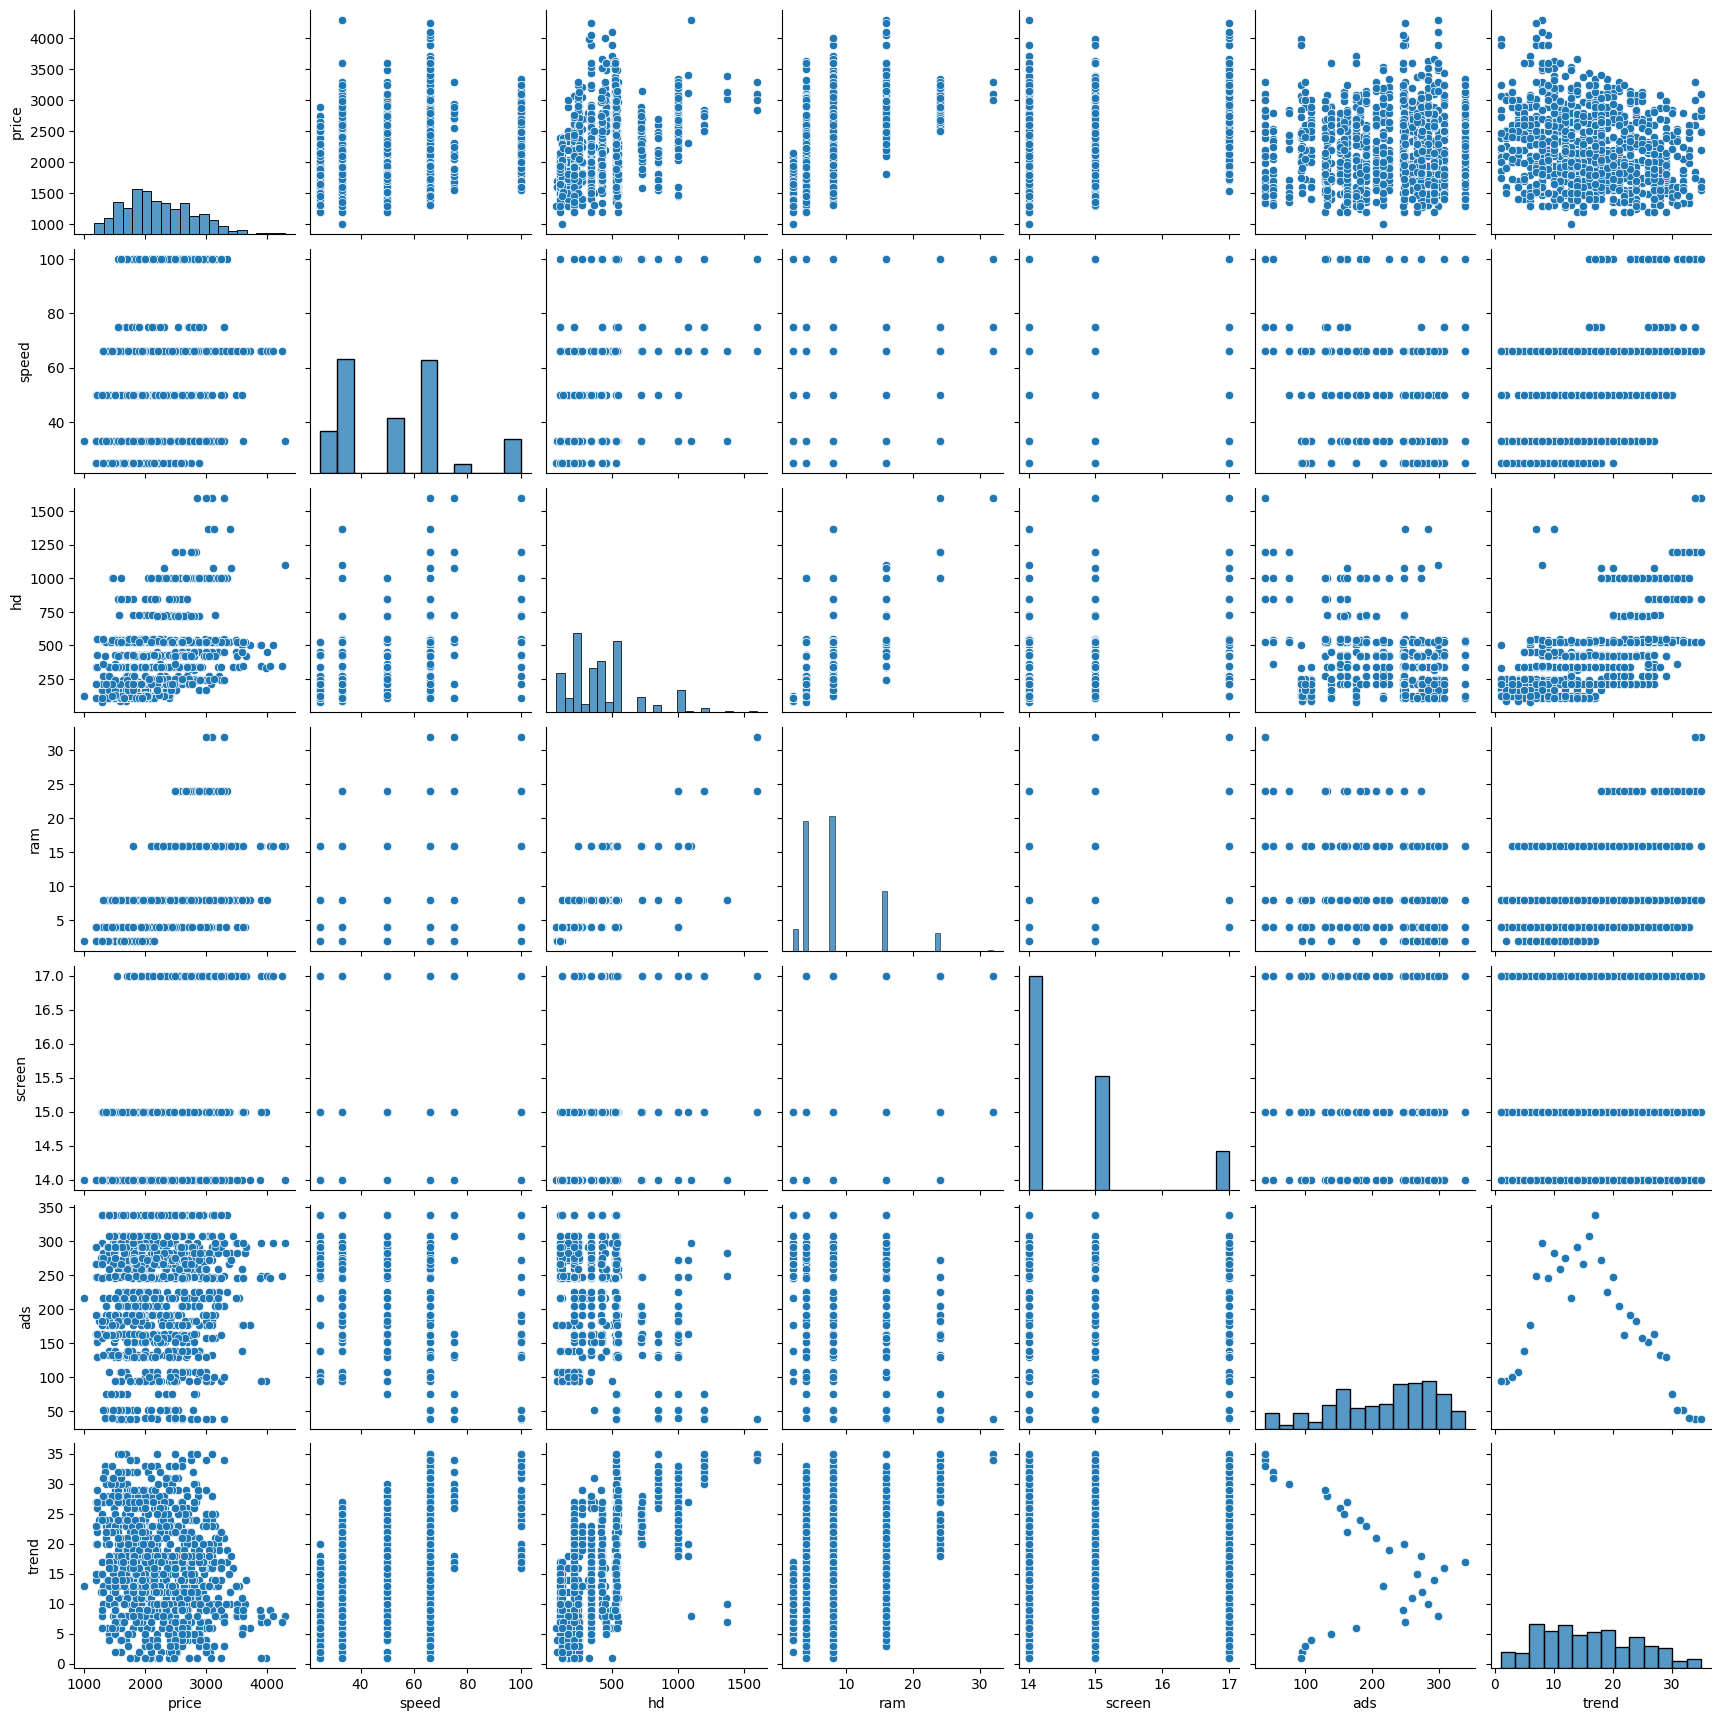

In [33]:
#Build a pairplot of numeric features in the data. Hint: df.select_dtypes("number") selects numeric columns. Consider sampling with df.sample(1000) to speed this up if it takes too long.
sns.pairplot(computers.select_dtypes("number").sample(1000))

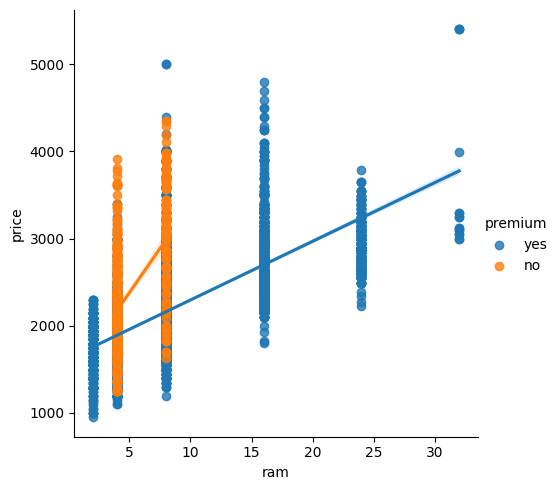

In [34]:
#Build an lmplot of ram vs. price. Does being a premium model (premium == 'yes') impact this relationship? Hint: use the hue argument to color by premium.
sns.lmplot(data=computers, x="ram", y="price", hue="premium")